# Workflow

1. Import data: Train and Test data

2. GroupShuffleSplit for an initial subject-aware train/validation split

3. Train different neural network baseline architectures

4. Use Early Stopping while monitoring validation loss

5. Compare training and validation curves

6. 5-fold StratifiedGroupKFold for subject-aware cross-validation

7. Choose the best architecture using mean CV Macro F1-score

8. Train the selected architecture again with Early Stopping

9. Evaluate once on X_test_arr

10. Analyze Classification Report and Confusion Matrix


In [15]:
import sys
import sklearn
import numpy as np
import pandas as pd
import random


from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GroupKFold

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from plotly import graph_objects as go
import matplotlib.pyplot as plt


In [16]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

## 1. Import data

In [17]:
x_train = pd.read_csv('human+activity+recognition+using+smartphones/UCI HAR Dataset/train/X_train.txt',
    sep=r"\s+",  
    header=None)
print(x_train.shape)

y_train = pd.read_csv('human+activity+recognition+using+smartphones/UCI HAR Dataset/train/y_train.txt',
    sep=r"\s+", 
    header=None,
    names=["activity"])

print(y_train.shape)


(7352, 561)
(7352, 1)


In [18]:
x_test = pd.read_csv('human+activity+recognition+using+smartphones/UCI HAR Dataset/test/X_test.txt',
    sep=r"\s+",  
    header=None)

print(x_test.shape)


y_test = pd.read_csv('human+activity+recognition+using+smartphones/UCI HAR Dataset/test/y_test.txt',
    sep=r"\s+",  
    header=None,
    names=["activity"])

print(y_test.shape)

(2947, 561)
(2947, 1)


In [19]:
subject_train = pd.read_csv(
    'human+activity+recognition+using+smartphones/UCI HAR Dataset/train/subject_train.txt',
    sep=r"\s+",  # regex \s whitespace, + one or more
    header=None,
    names=["subject"]

    )

subject_train_arr = subject_train.values.ravel()

In [20]:
X_train_arr = x_train.to_numpy()
y_train_arr = y_train.to_numpy().ravel()

X_test_arr = x_test.to_numpy()
y_test_arr = y_test.to_numpy().ravel()


# Adattare le 6 classi alla SparseCategoricalCrossentropy che ha indici da 0 e non da 1

y_train_dl = y_train_arr - 1  
y_test_dl = y_test_arr - 1

In [21]:
y_test_dl.shape

(2947,)

### Split train - val 

#### Usiamo GroupShuffleSplit per evitare che un soggetto si ritrovi nel train e nel val set.

In [22]:
gss = GroupShuffleSplit(
    n_splits=1,  # un unico split
    test_size=0.2,
    random_state=42 # fixed seed
)

train_idx, val_idx = next(
    gss.split(   # split method generats indices to split data 
        X_train_arr,
        y_train_dl,
        groups=subject_train_arr
    )
)

x_tr = X_train_arr[train_idx]
x_val = X_train_arr[val_idx]

y_tr = y_train_dl[train_idx]
y_val = y_train_dl[val_idx]

Sanity check del protocollo cross-subject 

In [23]:
train_subjects = np.unique(subject_train_arr[train_idx])
val_subjects = np.unique(subject_train_arr[val_idx])

print("Soggetti train set :", train_subjects)
print("Soggetti validation set subjects:", val_subjects)

print(
    "Soggetti in entrambi sets:",
    np.intersect1d(train_subjects, val_subjects)
)

Soggetti train set : [ 5  6  7  8 11 14 16 17 19 21 22 23 26 28 29 30]
Soggetti validation set subjects: [ 1  3 15 25 27]
Soggetti in entrambi sets: []


Train, val and test sets shape

In [24]:
# 1. Print the shapes to diagnose the issue
print("X_train shape:", x_tr.shape) 
print("y_train shape:", y_tr.shape) 
print("X_val shape:", x_val.shape)   
print("y_val shape:", y_val.shape)   

print("X_test shape:", X_test_arr.shape)   
print("y_test shape:", y_test_dl.shape)  

X_train shape: (5551, 561)
y_train shape: (5551,)
X_val shape: (1801, 561)
y_val shape: (1801,)
X_test shape: (2947, 561)
y_test shape: (2947,)


## Models 

In [25]:
model_baseline = keras.Sequential(

    [
    layers.Input(shape=(561,)),

    layers.Dense(64, activation="relu"),
   
    layers.Dense(32, activation="relu"),

    layers.Dense(6, activation="softmax")
])



model_dropout = keras.Sequential(

    [
    layers.Input(shape=(561,)),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(6, activation="softmax")
])



model_3 = keras.Sequential(

    [
    layers.Input(shape=(561,)),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(6, activation="softmax")
])



model_4 = keras.Sequential(

    [
    layers.Input(shape=(561,)),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(6, activation="softmax")
])





In [26]:
models = {
    "Baseline": model_baseline,
    "Baseline + 0.3 Dropout": model_dropout,
    "Smaller model + 0.3 Dropout ": model_3,
    "Bigger Model + 0.3 Dropout": model_4
}

## Training

In [27]:
histories = {}
f1_histories = {}

for name, model in models.items():


    model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
             #keras.metrics.F1Score(average='macro', name = 'f1_macro')]
)


    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )


    history = model.fit(
        x_tr,
        y_tr,
        validation_data=(x_val, y_val),
        epochs=80,
        batch_size=32,
       callbacks=[early_stopping],


        verbose=1
    )

    histories[name] = history

Epoch 1/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7993 - loss: 0.5538 - val_accuracy: 0.8806 - val_loss: 0.3637
Epoch 2/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9088 - loss: 0.2254 - val_accuracy: 0.9023 - val_loss: 0.2915
Epoch 3/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9328 - loss: 0.1649 - val_accuracy: 0.9178 - val_loss: 0.2466
Epoch 4/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9409 - loss: 0.1463 - val_accuracy: 0.9234 - val_loss: 0.2147
Epoch 5/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9514 - loss: 0.1167 - val_accuracy: 0.9278 - val_loss: 0.2134
Epoch 6/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9604 - loss: 0.0995 - val_accuracy: 0.9284 - val_loss: 0.2193
Epoch 7/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9654 - loss: 0.0899 - val_accuracy: 0.9306 - val_loss: 0.2126
Epoch 8/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9683 - loss: 0.0825 - val_accuracy: 0.

### Evaluation

Plot loss and f1 score

In [28]:
def plot_loss(history, model_name):

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["loss"],
        label="Training Loss"
    )

    plt.plot(
        history.history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} - Training vs Validation Loss")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

In [29]:
def plot_accuracy(history, model_name):

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history["accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history.history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} - Training vs Validation Accuracy")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

In [30]:
# Print loss history for every model
for name, history in histories.items():
    print(f"\n{name}")
    print("Training loss:")
    print(history.history["loss"])

    print("Validation loss:")
    print(history.history["val_loss"])


Baseline
Training loss:
[0.553752601146698, 0.22543393075466156, 0.1648641973733902, 0.14633144438266754, 0.11671072989702225, 0.09948830306529999, 0.08992539346218109, 0.08253397047519684, 0.0761088877916336, 0.07063693553209305, 0.06828573346138, 0.06340032815933228, 0.06256922334432602, 0.058664605021476746, 0.0571744479238987, 0.05517277866601944, 0.05194816365838051, 0.05091586709022522, 0.051027219742536545, 0.04868854582309723, 0.0493752546608448, 0.04966964200139046, 0.04541997238993645, 0.04369013383984566, 0.05050867423415184, 0.053156930953264236, 0.04235644266009331, 0.03964700177311897, 0.03992448002099991, 0.03839047625660896, 0.03740789368748665, 0.03514483571052551, 0.04477563872933388, 0.041124407202005386, 0.033267732709646225, 0.03282691538333893, 0.029234295710921288, 0.029111774638295174, 0.027408014982938766, 0.028164051473140717, 0.02863902598619461, 0.028556937351822853, 0.037738483399152756, 0.03147885948419571, 0.04269905015826225, 0.028427384793758392, 0.024

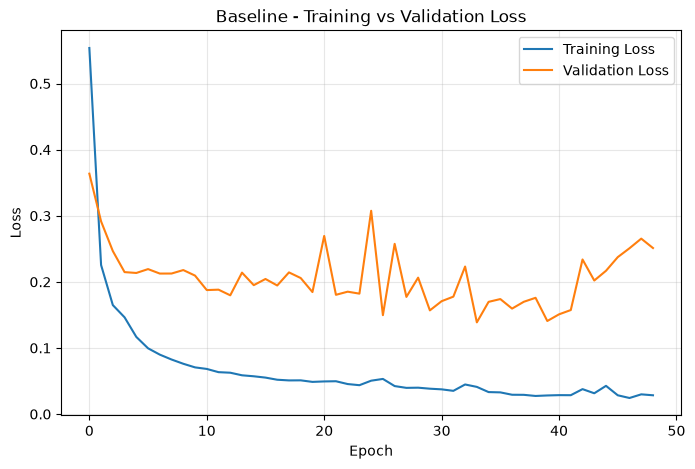

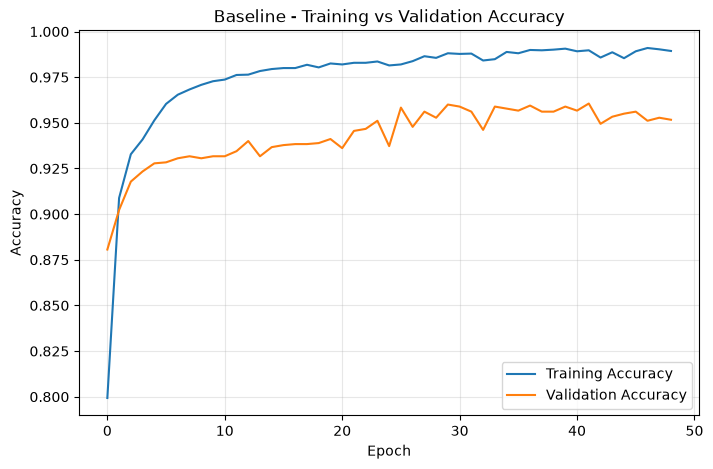

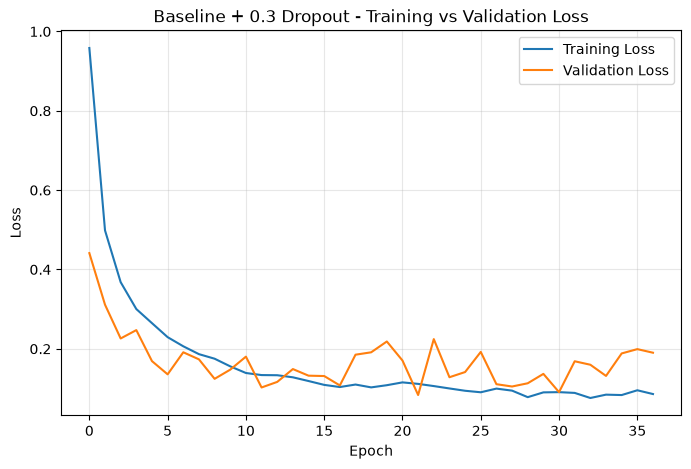

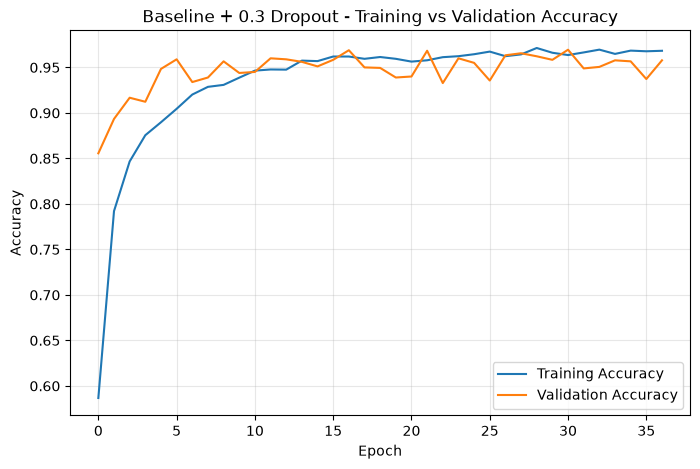

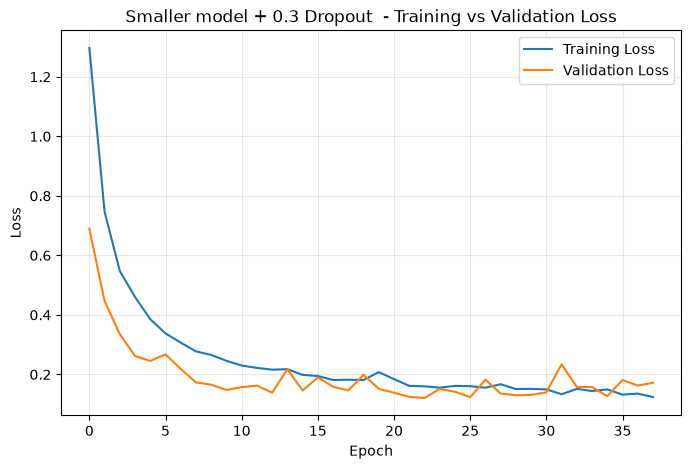

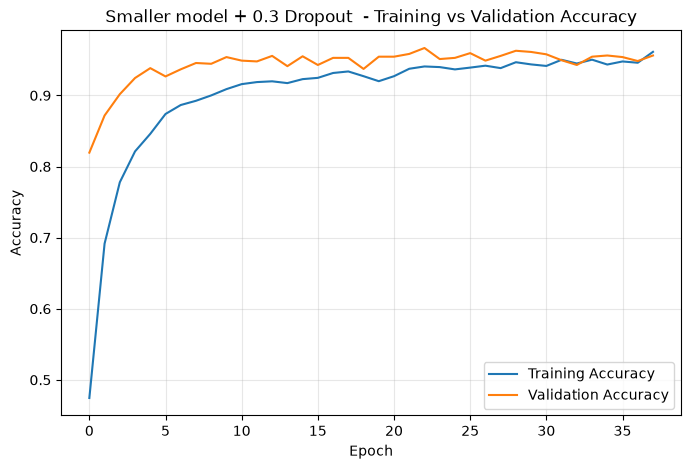

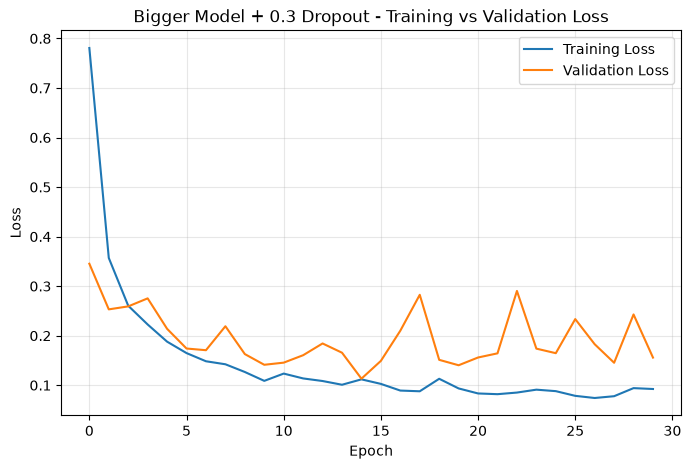

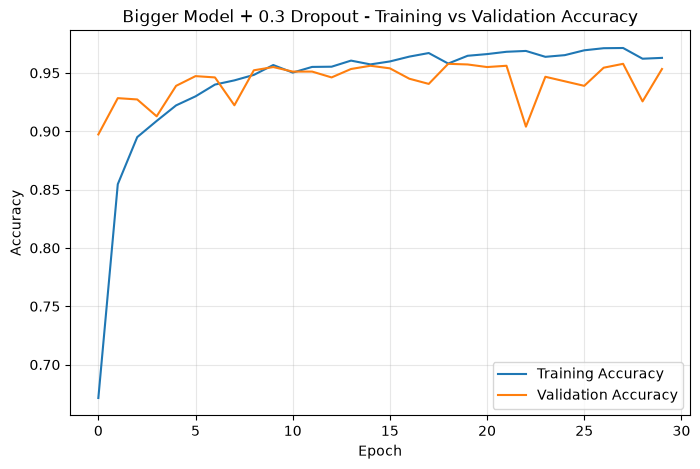

In [31]:
for name in models:

    plot_loss(
        histories[name],
        name
    )

    plot_accuracy(
        histories[name],
        name
    )

In [32]:
train_results = []
validation_results = []

for name, model, in models.items():

    y_prob_train = model.predict(x_tr)
    y_pred_train = np.argmax(y_prob_train, axis=1)

    y_prob_val = model.predict(x_val)
    y_pred_val = np.argmax(y_prob_val, axis=1)


    report_train = classification_report(
        y_tr,
        y_pred_train,
        output_dict= True

    )

    report_val = classification_report(
        y_val,
        y_pred_val,
        output_dict=True,
        zero_division=0
    )

    train_results.append({
        'Model':name,
        "Accuracy": report_train['accuracy'],
        "Precision":report_train['macro avg']['precision'],
        "Recall":report_train['macro avg']['recall'],
        "F1": report_train['macro avg']['f1-score']
                          })

    validation_results.append({
        'Model':name,
        "Accuracy": report_val['accuracy'],
        "Precision":report_val['macro avg']['precision'],
        "Recall":report_val['macro avg']['recall'],
        "F1": report_val['macro avg']['f1-score']
                          })

train_results_df = pd.DataFrame(train_results)
print('--TRAIN SET---')

display(train_results_df.round(4))

validation_results_df = pd.DataFrame(validation_results)
print('--VALIDATION SET---')
display(validation_results_df.round(4))

174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 520us/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 523us/step
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 829us/step
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 483us/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 496us/step
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step
--TRAIN SET---


,Model,Accuracy,Precision,Recall,F1
0,Baseline,0.9832,0.9861,0.9845,0.9848
1,Baseline + 0.3 Dropout,0.9811,0.9838,0.9824,0.9827
2,Smaller model + 0.3 Dropout,0.9816,0.9839,0.9831,0.9833
3,Bigger Model + 0.3 Dropout,0.9679,0.9746,0.9700,0.9704


--VALIDATION SET---


,Model,Accuracy,Precision,Recall,F1
0,Baseline,0.9589,0.9596,0.9538,0.9552
1,Baseline + 0.3 Dropout,0.9684,0.9695,0.9646,0.9661
2,Smaller model + 0.3 Dropout,0.9667,0.9648,0.9634,0.9636
3,Bigger Model + 0.3 Dropout,0.9561,0.9578,0.9506,0.9529


In [33]:
from sklearn.metrics import f1_score

for name, model in models.items():

    # Loss and accuracy
    train_results = model.evaluate(
        x_tr, y_tr,
        verbose=0,
        return_dict=True
    )

    val_results = model.evaluate(
        x_val, y_val,
        verbose=0,
        return_dict=True
    )

    # F1
    y_train_pred = np.argmax(
        model.predict(x_tr, verbose=0),
        axis=1
    )

    y_val_pred = np.argmax(
        model.predict(x_val, verbose=0),
        axis=1
    )

    train_f1 = f1_score(
        y_tr,
        y_train_pred,
        average="macro"
    )

    val_f1 = f1_score(
        y_val,
        y_val_pred,
        average="macro"
    )

    print(f"\n{name}")
    print(f"Train loss: {train_results['loss']:.4f}")
    print(f"Val loss:   {val_results['loss']:.4f}")
    print(f"Train acc:  {train_results['accuracy']:.4f}")
    print(f"Val acc:    {val_results['accuracy']:.4f}")
    print(f"Train F1:   {train_f1:.4f}")
    print(f"Val F1:     {val_f1:.4f}")


Baseline
Train loss: 0.0411
Val loss:   0.1387
Train acc:  0.9832
Val acc:    0.9589
Train F1:   0.9848
Val F1:     0.9552

Baseline + 0.3 Dropout
Train loss: 0.0514
Val loss:   0.0835
Train acc:  0.9811
Val acc:    0.9684
Train F1:   0.9827
Val F1:     0.9661

Smaller model + 0.3 Dropout 
Train loss: 0.0540
Val loss:   0.1207
Train acc:  0.9816
Val acc:    0.9667
Train F1:   0.9833
Val F1:     0.9636

Bigger Model + 0.3 Dropout
Train loss: 0.0738
Val loss:   0.1132
Train acc:  0.9679
Val acc:    0.9561
Train F1:   0.9704
Val F1:     0.9529


Best epoch 

In [34]:
for name, history in histories.items():

    best_epoch = np.argmin(history.history["val_loss"]) + 1
    best_val_loss = np.min(history.history["val_loss"])

    print(f"\n{name}")
    print(f"Best epoch: {best_epoch}")
    print(f"Best validation loss: {best_val_loss:.4f}")


Baseline
Best epoch: 34
Best validation loss: 0.1387

Baseline + 0.3 Dropout
Best epoch: 22
Best validation loss: 0.0835

Smaller model + 0.3 Dropout 
Best epoch: 23
Best validation loss: 0.1207

Bigger Model + 0.3 Dropout
Best epoch: 15
Best validation loss: 0.1132



print("Best validation loss:", best_val_loss)

## B. Cross Validation

#### Addestramento di tutte le configurazioni di modelli mediante cross-validation al fine di selezionare il modello più performante sull'intero dataset.

Check

In [35]:
print(X_train_arr.shape)
print(y_train_arr.shape)
print(subject_train_arr.shape)
print(np.unique(subject_train_arr))

(7352, 561)
(7352,)
(7352,)
[ 1  3  5  6  7  8 11 14 15 16 17 19 21 22 23 25 26 27 28 29 30]


In [36]:
from sklearn.model_selection import StratifiedGroupKFold

stratified_group_kfold = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Each model is a function

In [37]:
def build_baseline():

    model_baseline = keras.Sequential(

        [
        layers.Input(shape=(561,)),

        layers.Dense(64, activation="relu"),

        layers.Dense(32, activation="relu"),

        layers.Dense(6, activation="softmax")
    ])
    
    return model_baseline

def build_model_2():

    build_model_2 = keras.Sequential(

    [
    layers.Input(shape=(561,)),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(6, activation="softmax")
    ])


    return build_model_2

def build_model_3():

    build_model_3 = keras.Sequential(

    [
    layers.Input(shape=(561,)),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(6, activation="softmax")
    ])

    return build_model_3

def build_model_4():

    build_model_4 = keras.Sequential(

    [
    layers.Input(shape=(561,)),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(6, activation="softmax")
])

    return build_model_4

Model builder for applying cross-validation

In [38]:
model_builders = {
    "Baseline": build_baseline,
    "Baseline + 0.3 Dropout": build_model_2,
    "Smaller + 0.3 Dropout": build_model_3,
    "Bigger + 0.3 Dropout": build_model_4
}

In [39]:
for fold, (train_idx, val_idx) in enumerate(
    stratified_group_kfold.split(
        X_train_arr,
        y_train_dl,
        groups=subject_train_arr
    ),
    start=1
):

    train_subjects = np.unique(subject_train_arr[train_idx])
    val_subjects = np.unique(subject_train_arr[val_idx])

    print(f"\nFold {fold}")
    print("Overlap:", np.intersect1d(train_subjects, val_subjects))

    classes, counts = np.unique(
        y_train_dl[val_idx],
        return_counts=True
    )
    print(dict(zip(classes, counts)))


Fold 1
Overlap: []
{np.int64(0): np.int64(245), np.int64(1): np.int64(225), np.int64(2): np.int64(207), np.int64(3): np.int64(271), np.int64(4): np.int64(275), np.int64(5): np.int64(305)}

Fold 2
Overlap: []
{np.int64(0): np.int64(261), np.int64(1): np.int64(202), np.int64(2): np.int64(197), np.int64(3): np.int64(228), np.int64(4): np.int64(255), np.int64(5): np.int64(244)}

Fold 3
Overlap: []
{np.int64(0): np.int64(277), np.int64(1): np.int64(234), np.int64(2): np.int64(216), np.int64(3): np.int64(284), np.int64(4): np.int64(305), np.int64(5): np.int64(317)}

Fold 4
Overlap: []
{np.int64(0): np.int64(229), np.int64(1): np.int64(211), np.int64(2): np.int64(189), np.int64(3): np.int64(259), np.int64(4): np.int64(270), np.int64(5): np.int64(264)}

Fold 5
Overlap: []
{np.int64(0): np.int64(214), np.int64(1): np.int64(201), np.int64(2): np.int64(177), np.int64(3): np.int64(244), np.int64(4): np.int64(269), np.int64(5): np.int64(277)}


### Training

Addestriamo tutte le architetture di rete tramite una loop for.

In [40]:
histories = {}
cv_results = {}

for model_name, build_model in model_builders.items():

    histories[model_name] = []
    cv_results[model_name] = []

    for fold, (train_idx, val_idx) in enumerate(
        stratified_group_kfold.split(
            X_train_arr,
            y_train_dl,
            groups=subject_train_arr
        ),
        start=1
    ):

        # Fold data
        x_fold_train = X_train_arr[train_idx]
        y_fold_train = y_train_dl[train_idx]

        x_fold_val = X_train_arr[val_idx]
        y_fold_val = y_train_dl[val_idx]

        tf.keras.utils.set_random_seed(42)

        # Fresh model for each fold
        model = build_model()

        model.compile(
            optimizer=keras.optimizers.Adam(
                learning_rate=1e-3
            ),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        early_stopping = keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )

        history = model.fit(
            x_fold_train,
            y_fold_train,
            validation_data=(x_fold_val, y_fold_val),
            epochs=80,
            batch_size=32,
            callbacks=[early_stopping],
            verbose=0
        )

        # Best epoch according to validation loss
        best_epoch = (
            np.argmin(history.history["val_loss"]) + 1
        )

        # Since restore_best_weights=True,
        # model now contains the weights from best_epoch
        y_val_pred = np.argmax(
            model.predict(
                x_fold_val,
                verbose=0
            ),
            axis=1
        )

        report = classification_report(
            y_fold_val,
            y_val_pred,
            output_dict=True,
            zero_division=0
        )

        cm = confusion_matrix(
            y_fold_val,
            y_val_pred
        )

        cv_results[model_name].append({
            "fold": fold,
            "best_epoch": best_epoch,
            "accuracy": report["accuracy"],
            "precision": report["macro avg"]["precision"],
            "recall": report["macro avg"]["recall"],
            "f1": report["macro avg"]["f1-score"],
            "report": report,
            "confusion_matrix": cm,
            "val_idx": val_idx,
            "y_true": y_fold_val,
            "y_pred": y_val_pred
        })

        histories[model_name].append(history)

        print(
            f"Fold {fold} | "
            f"Best epoch: {best_epoch} | "
            f"F1: {report['macro avg']['f1-score']:.4f}"
        )

Fold 1 | Best epoch: 21 | F1: 0.9363
Fold 2 | Best epoch: 3 | F1: 0.9302
Fold 3 | Best epoch: 8 | F1: 0.9595
Fold 4 | Best epoch: 1 | F1: 0.8084
Fold 5 | Best epoch: 33 | F1: 0.9811
Fold 1 | Best epoch: 52 | F1: 0.9542
Fold 2 | Best epoch: 6 | F1: 0.9142
Fold 3 | Best epoch: 14 | F1: 0.9579
Fold 4 | Best epoch: 7 | F1: 0.8241
Fold 5 | Best epoch: 22 | F1: 0.9834
Fold 1 | Best epoch: 29 | F1: 0.9435
Fold 2 | Best epoch: 8 | F1: 0.9178
Fold 3 | Best epoch: 22 | F1: 0.9643
Fold 4 | Best epoch: 19 | F1: 0.8681
Fold 5 | Best epoch: 31 | F1: 0.9811
Fold 1 | Best epoch: 21 | F1: 0.9447
Fold 2 | Best epoch: 4 | F1: 0.9248
Fold 3 | Best epoch: 13 | F1: 0.9633
Fold 4 | Best epoch: 1 | F1: 0.7644
Fold 5 | Best epoch: 14 | F1: 0.9796


### Risultati

In [41]:
for model_name, results in cv_results.items():

    f1_scores = [r["f1"] for r in results]
    accuracies = [r["accuracy"] for r in results]
    best_epochs = [r["best_epoch"] for r in results]

    print(f"\n===== {model_name} =====")
    print("F1 per fold:", np.round(f1_scores, 4))
    print(f"Mean F1: {np.mean(f1_scores):.4f}")
    print(f"Std F1:  {np.std(f1_scores):.4f}")

    print(f"Mean Accuracy: {np.mean(accuracies):.4f}")
    print("Best epochs:", best_epochs)


===== Baseline =====
F1 per fold: [0.9363 0.9302 0.9595 0.8084 0.9811]
Mean F1: 0.9231
Std F1:  0.0601
Mean Accuracy: 0.9248
Best epochs: [np.int64(21), np.int64(3), np.int64(8), np.int64(1), np.int64(33)]

===== Baseline + 0.3 Dropout =====
F1 per fold: [0.9542 0.9142 0.9579 0.8241 0.9834]
Mean F1: 0.9268
Std F1:  0.0559
Mean Accuracy: 0.9268
Best epochs: [np.int64(52), np.int64(6), np.int64(14), np.int64(7), np.int64(22)]

===== Smaller + 0.3 Dropout =====
F1 per fold: [0.9435 0.9178 0.9643 0.8681 0.9811]
Mean F1: 0.9349
Std F1:  0.0396
Mean Accuracy: 0.9354
Best epochs: [np.int64(29), np.int64(8), np.int64(22), np.int64(19), np.int64(31)]

===== Bigger + 0.3 Dropout =====
F1 per fold: [0.9447 0.9248 0.9633 0.7644 0.9796]
Mean F1: 0.9153
Std F1:  0.0777
Mean Accuracy: 0.9174
Best epochs: [np.int64(21), np.int64(4), np.int64(13), np.int64(1), np.int64(14)]


## Addestramento e inferenza del modello selezionato sur test set

Modello "Smaller + 0.3 Dropout"

In [42]:

gss_final = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    gss_final.split(
        X_train_arr,
        y_train_dl,
        groups=subject_train_arr
    )
)

x_final_train = X_train_arr[train_idx]
y_final_train = y_train_dl[train_idx]

x_final_val = X_train_arr[val_idx]
y_final_val = y_train_dl[val_idx]

In [43]:
tf.keras.utils.set_random_seed(42)

final_model = build_model_3()

final_model.summary()

final_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

final_history = final_model.fit(
    x_final_train,
    y_final_train,
    validation_data=(
        x_final_val,
        y_final_val
    ),
    epochs=80,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_84 (Dense)                │ (None, 32)             │        17,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,614 (72.71 KB)

 Trainable params: 18,614 (72.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4635 - loss: 1.2679 - val_accuracy: 0.8212 - val_loss: 0.6975
Epoch 2/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6840 - loss: 0.7642 - val_accuracy: 0.8962 - val_loss: 0.3930
Epoch 3/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 977us/step - accuracy: 0.7667 - loss: 0.5573 - val_accuracy: 0.8540 - val_loss: 0.3673
Epoch 4/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - accuracy: 0.8190 - loss: 0.4365 - val_accuracy: 0.9384 - val_loss: 0.2231
Epoch 5/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step - accuracy: 0.8532 - loss: 0.3654 - val_accuracy: 0.9384 - val_loss: 0.2005
Epoch 6/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step - accuracy: 0.8698 - loss: 0.3357 - val_accuracy: 0.9428 - val_loss: 0.2012
Epoch 7/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - accuracy: 0.8845 - loss: 0.2949 - val_accuracy: 0.9373 - val_loss: 0.2352
Epoch 8/80
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step - accuracy: 0.8962 - loss: 0.2643 - val_

### Evaluation


Classification Report:
              precision    recall  f1-score   support

           0     0.9272    0.9758    0.9509       496
           1     0.9644    0.9214    0.9425       471
           2     0.9617    0.9571    0.9594       420
           3     0.9557    0.8778    0.9151       491
           4     0.8998    0.9624    0.9301       532
           5     1.0000    1.0000    1.0000       537

    accuracy                         0.9501      2947
   macro avg     0.9515    0.9491    0.9497      2947
weighted avg     0.9511    0.9501    0.9500      2947

Test Macro F1-score: 0.9497


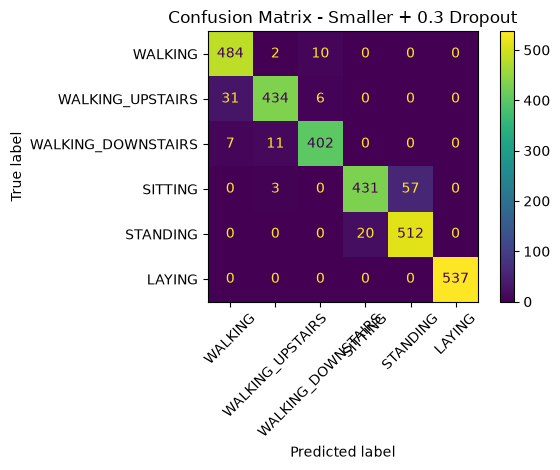

In [44]:
# Final predictions 
y_test_prob = final_model.predict(
    X_test_arr,
    verbose=0
)

y_test_pred = np.argmax(
    y_test_prob,
    axis=1
)

# Classification report
print("\nClassification Report:")

print(
    classification_report(
        y_test_dl,
        y_test_pred,
        digits=4
    )
)


f1 = f1_score(
    y_test_dl,
    y_test_pred,
    average="macro"
)

print(f"Test Macro F1-score: {f1:.4f}")

# Matrice di confusion
cm = confusion_matrix(
    y_test_dl,
    y_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "WALKING",
        "WALKING_UPSTAIRS",
        "WALKING_DOWNSTAIRS",
        "SITTING",
        "STANDING",
        "LAYING"
    ]
)

disp.plot(
    xticks_rotation=45
)

plt.title("Confusion Matrix - Smaller + 0.3 Dropout")
plt.tight_layout()
plt.show()